In [29]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [30]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [ ]:
df = pd.read_sql("""
    SELECT timestamp, uid
    FROM checker
    WHERE status = 'ready'
      AND uid NOT LIKE 'admin%'
""", conn)


df['timestamp'] = pd.to_datetime(df['timestamp'])

In [32]:
# извлекаем час и день недели
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday

# определяем тип дня: weekend / working_day
df['day_type'] = df['weekday'].apply(lambda x: 'weekend' if x >= 5 else 'working_day')

In [33]:
weekend_hours = df[df['day_type'] == 'weekend']['hour'].tolist()
working_hours = df[df['day_type'] == 'working_day']['hour'].tolist()

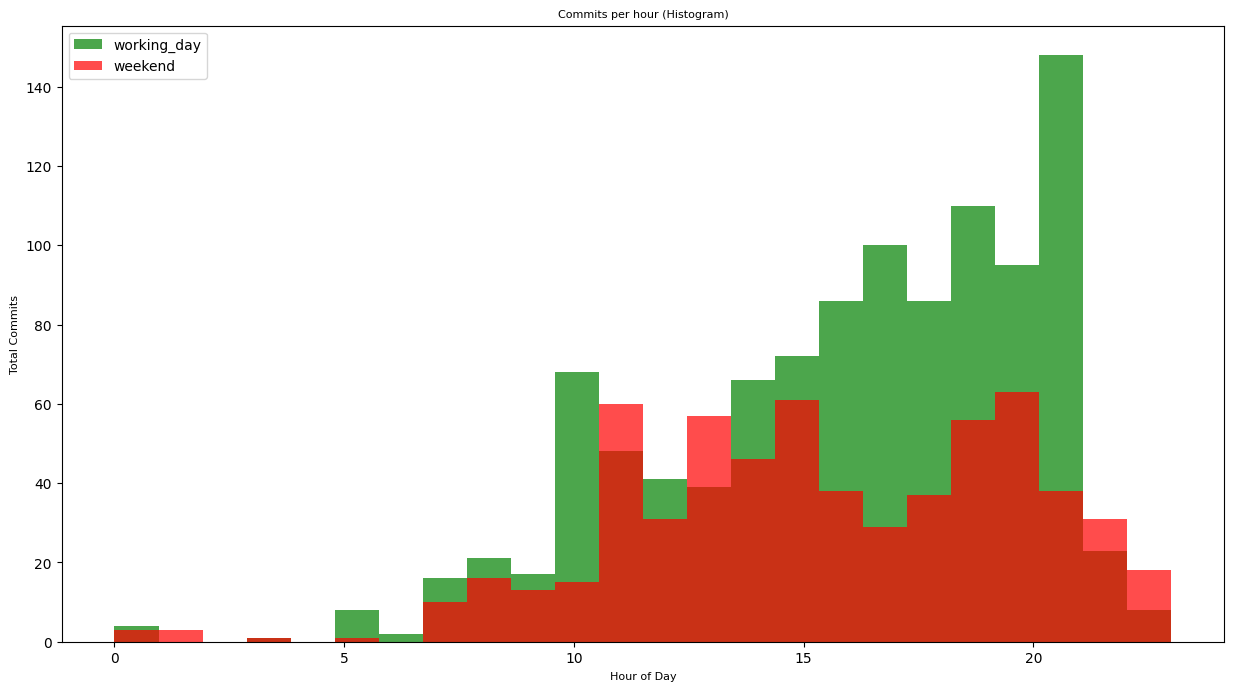

In [ ]:
# создаём фигуру
plt.figure(figsize=(15, 8))

# строим гистограмму
plt.hist(working_hours, bins=24, alpha=0.7, label='working_day', color='green')
plt.hist(weekend_hours, bins=24, alpha=0.7, label='weekend', color='red')


plt.title('Commits per hour (Histogram)', fontsize=8)
plt.xlabel('Hour of Day', fontsize=8)
plt.ylabel('Total Commits', fontsize=8)
plt.legend()
plt.xticks(range(0, 24, 5)) 
plt.show()

11 13 22 23

In [35]:
conn.close()